In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import seaborn as sns
sns.set_style("whitegrid")
from scipy import stats
from ipywidgets import interact, fixed
from sklearn.datasets import make_blobs, make_circles
from mpl_toolkits import mplot3d

df = pd.read_csv(r"D:\data_mining\tuan9\data_banknote_authentication.txt",header=None)
df

,0,1,2,3,4
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [24]:
from sklearn.decomposition import PCA

y = df.iloc[:, 4]
X = df.iloc[:, 0:4]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(X_pca)

[[ 1.47280494  1.16391668 -0.16725349]
 [ 1.63944068  1.09381204  0.37118695]
 [-0.51391884  1.32487953  0.50911186]
 ...
 [-4.04932734 -2.03602288  1.78592393]
 [-3.01961738 -1.39214023  0.68147895]
 [-1.17058249 -0.09103094 -1.11306082]]


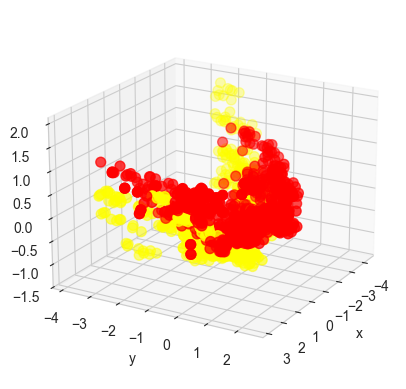

In [25]:
ax = plt.subplot(projection='3d')
ax.scatter3D(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, s=50, cmap='autumn')
ax.view_init(elev=20, azim=30)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r')
plt.show()

=> Đây là dữ liệu không tuyến tính

In [28]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca)

[[ 1.47280494  1.16391668]
 [ 1.63944068  1.09381204]
 [-0.51391884  1.32487953]
 ...
 [-4.04932734 -2.03602288]
 [-3.01961738 -1.39214023]
 [-1.17058249 -0.09103094]]


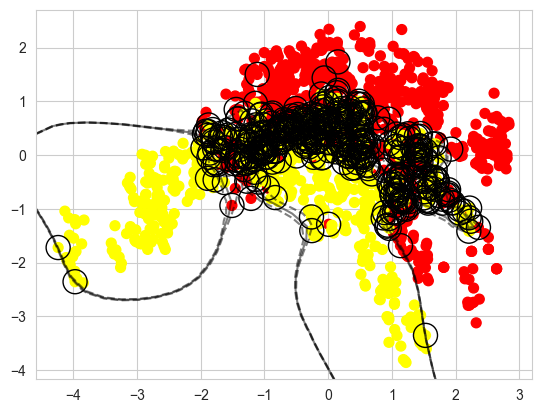

array([[-1.19341594e+00, -2.46536664e-02],
       [-1.92137618e+00,  4.42153101e-01],
       [ 1.25787420e+00,  3.96475476e-01],
       [ 9.58679069e-01, -1.17962292e+00],
       [ 1.34166468e-01,  1.15944488e+00],
       [-6.20875027e-01,  5.28398552e-01],
       [-1.19341944e+00, -2.46642879e-02],
       [-1.25336907e+00,  2.56434805e-01],
       [ 1.00090203e+00, -1.07124624e+00],
       [-1.03906771e+00,  1.19562236e-01],
       [-3.07581176e-01,  7.06391729e-01],
       [ 1.16629255e+00, -3.49602222e-01],
       [ 1.06608220e-01,  4.55288483e-01],
       [-1.95289922e-01,  6.41851237e-01],
       [ 2.09610694e-01,  1.90275167e-01],
       [-4.07101188e-01,  6.63887257e-01],
       [-1.01330409e-01,  9.49505593e-01],
       [ 1.30611742e+00, -4.35926471e-01],
       [ 1.55763871e-01,  1.00061698e+00],
       [ 2.83655627e-01, -9.56818975e-03],
       [ 6.06034353e-01,  1.25346453e-02],
       [-3.81030116e-01,  7.12868830e-01],
       [ 1.32701696e+00, -1.48054766e-01],
       [ 4.

In [29]:
model = SVC(kernel='rbf', C=1E6)
model.fit(X_pca, y)

def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--','-','--'])
    
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidths=1, edgecolors='black',
                   facecolors='none')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)
plt.show()
model.support_vectors_